In [1]:
import os
import math
import random
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.ndimage import zoom, rotate
from sklearn.model_selection import train_test_split

FS_OUTPUT     = "E:/Oasis3/FastSurfer_output"
PET_REG       = "E:/Oasis3/PET_registered_v2"
COHORT_CSV    = "D:/mamba_model/thesis_cohort_final.csv"

WB_MRI_CACHE      = "D:/mamba_model/preprocessed_cache_wholebrain_mri"
WB_MRI_CACHE_AUG  = "D:/mamba_model/preprocessed_cache_wholebrain_mri_aug"
WB_PET_CACHE      = "D:/mamba_model/preprocessed_cache_wholebrain_pet"
WB_PET_CACHE_AUG  = "D:/mamba_model/preprocessed_cache_wholebrain_pet_aug"

for d in [WB_MRI_CACHE, WB_MRI_CACHE_AUG, WB_PET_CACHE, WB_PET_CACHE_AUG]:
    os.makedirs(d, exist_ok=True)

AUG_SEEDS = [1, 101, 42]

In [2]:
CURRENT_TOKENS = 3072  # matches 6 ROIs * 8^3 patches
PATCH_SIZE = 8

patches_per_side_needed = round((CURRENT_TOKENS * PATCH_SIZE**3) ** (1/3) / PATCH_SIZE)
raw_target = patches_per_side_needed * PATCH_SIZE
TARGET_SIZE = math.ceil(raw_target / PATCH_SIZE) * PATCH_SIZE

grid_size = TARGET_SIZE // PATCH_SIZE
total_tokens = grid_size ** 3

print(f"Target whole-brain cube size: {TARGET_SIZE}^3")
print(f"Total tokens: {total_tokens} (vs current 6-ROI setup: {CURRENT_TOKENS})")

Target whole-brain cube size: 120^3
Total tokens: 3375 (vs current 6-ROI setup: 3072)


In [3]:
df = pd.read_csv(COHORT_CSV)
sessions, labels = df["mri_session"].values, df["outcome_label"].values

X_tv, X_test, y_tv, y_test = train_test_split(sessions, labels, test_size=0.2, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)
session_to_subject = dict(zip(df["mri_session"], df["subject_id"]))

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 126 | Val: 42 | Test: 42


In [4]:
failed_mri = []
for _, row in df.iterrows():
    session_id = row["mri_session"]
    orig_path = f"{FS_OUTPUT}/{session_id}/mri/orig.mgz"
    save_path = f"{WB_MRI_CACHE}/{session_id}.npy"

    if os.path.exists(save_path):
        continue
    if not os.path.exists(orig_path):
        failed_mri.append(session_id)
        continue

    try:
        vol = nib.load(orig_path).get_fdata()
        brain_voxels = vol[vol != 0]
        if len(brain_voxels) > 0 and brain_voxels.std() > 0:
            vol = np.where(vol != 0, (vol - brain_voxels.mean()) / brain_voxels.std(), 0)
        zoom_factors = [TARGET_SIZE / s for s in vol.shape]
        resized = zoom(vol, zoom_factors, order=1).astype(np.float32)
        np.save(save_path, resized)
        print(f"  MRI {session_id} done")
    except Exception as e:
        print(f"  FAILED MRI {session_id}: {e}")
        failed_mri.append(session_id)

print(f"\nMRI extracted: {len(df) - len(failed_mri)}/{len(df)}. Failed: {len(failed_mri)}")

  MRI OAS30564_MR_d2808 done
  MRI OAS31039_MR_d0001 done
  MRI OAS30473_MR_d0385 done
  MRI OAS30071_MR_d0018 done
  MRI OAS30194_MR_d7432 done
  MRI OAS31085_MR_d0504 done
  MRI OAS30818_MR_d1214 done
  MRI OAS30662_MR_d1483 done
  MRI OAS30830_MR_d0030 done
  MRI OAS30966_MR_d1923 done
  MRI OAS30589_MR_d2311 done
  MRI OAS30612_MR_d0039 done
  MRI OAS31013_MR_d0039 done
  MRI OAS30717_MR_d0039 done
  MRI OAS30978_MR_d0041 done
  MRI OAS30350_MR_d1201 done
  MRI OAS31056_MR_d0808 done
  MRI OAS30949_MR_d1418 done
  MRI OAS30211_MR_d0046 done
  MRI OAS30903_MR_d0046 done
  MRI OAS30532_MR_d0047 done
  MRI OAS30344_MR_d0049 done
  MRI OAS30998_MR_d0051 done
  MRI OAS30393_MR_d7726 done
  MRI OAS30749_MR_d1157 done
  MRI OAS30208_MR_d0436 done
  MRI OAS30254_MR_d0057 done
  MRI OAS30572_MR_d0058 done
  MRI OAS31124_MR_d0436 done
  MRI OAS30205_MR_d0061 done
  MRI OAS30007_MR_d0061 done
  MRI OAS31093_MR_d0063 done
  MRI OAS30132_MR_d0063 done
  MRI OAS30982_MR_d0063 done
  MRI OAS30687

In [5]:
failed_pet = []
for _, row in df.iterrows():
    subject_id = row["subject_id"]
    pet_path = f"{PET_REG}/{subject_id}_PIB_in_MRI.nii.gz"
    save_path = f"{WB_PET_CACHE}/{subject_id}.npy"

    if os.path.exists(save_path):
        continue
    if not os.path.exists(pet_path):
        failed_pet.append(subject_id)
        continue

    try:
        pet = nib.load(pet_path).get_fdata()
        if pet.ndim == 4:
            pet = pet.mean(axis=-1)
        brain_voxels = pet[pet != 0]
        if len(brain_voxels) > 0 and brain_voxels.std() > 0:
            pet = np.where(pet != 0, (pet - brain_voxels.mean()) / brain_voxels.std(), 0)
        zoom_factors = [TARGET_SIZE / s for s in pet.shape]
        resized = zoom(pet, zoom_factors, order=1).astype(np.float32)
        np.save(save_path, resized)
        print(f"  PET {subject_id} done")
    except Exception as e:
        print(f"  FAILED PET {subject_id}: {e}")
        failed_pet.append(subject_id)

print(f"\nPET extracted: {len(df) - len(failed_pet)}/{len(df)}. Failed: {len(failed_pet)}")

  PET OAS30564 done
  PET OAS31039 done
  PET OAS30473 done
  PET OAS30071 done
  PET OAS30194 done
  PET OAS31085 done
  PET OAS30818 done
  PET OAS30662 done
  PET OAS30830 done
  PET OAS30966 done
  PET OAS30589 done
  PET OAS30612 done
  PET OAS31013 done
  PET OAS30717 done
  PET OAS30978 done
  PET OAS30350 done
  PET OAS31056 done
  PET OAS30949 done
  PET OAS30211 done
  PET OAS30903 done
  PET OAS30532 done
  PET OAS30344 done
  PET OAS30998 done
  PET OAS30393 done
  PET OAS30749 done
  PET OAS30208 done
  PET OAS30254 done
  PET OAS30572 done
  PET OAS31124 done
  PET OAS30205 done
  PET OAS30007 done
  PET OAS31093 done
  PET OAS30132 done
  PET OAS30982 done
  PET OAS30687 done
  PET OAS31001 done
  PET OAS30908 done
  PET OAS31041 done
  PET OAS30038 done
  PET OAS30924 done
  PET OAS30848 done
  PET OAS30899 done
  PET OAS30028 done
  PET OAS30451 done
  PET OAS30939 done
  PET OAS30109 done
  PET OAS30863 done
  PET OAS30164 done
  PET OAS30869 done
  PET OAS30273 done


In [6]:
def augment_wholebrain(vol, seed):
    np.random.seed(seed)
    random.seed(seed)
    augmented = rotate(vol, np.random.uniform(-15, 15), reshape=False, mode="constant", cval=0)
    if np.random.random() > 0.5:
        augmented = augmented[::-1, :, :].copy()
    if np.random.random() > 0.5:
        augmented = augmented[:, ::-1, :].copy()
    return augmented.astype(np.float32)

In [7]:
copied, missing = 0, []
for session_id in df["mri_session"]:
    src = f"{WB_MRI_CACHE}/{session_id}.npy"
    dst = f"{WB_MRI_CACHE_AUG}/{session_id}_orig.npy"
    if os.path.exists(dst):
        continue
    if not os.path.exists(src):
        missing.append(session_id)
        continue
    np.save(dst, np.load(src))
    copied += 1
print(f"MRI: copied {copied} originals. Missing: {len(missing)}")

aug_done, aug_failed = 0, []
for seed in AUG_SEEDS:
    for session_id in X_train:
        save_path = f"{WB_MRI_CACHE_AUG}/{session_id}_aug{seed}.npy"
        if os.path.exists(save_path):
            continue
        try:
            orig = np.load(f"{WB_MRI_CACHE_AUG}/{session_id}_orig.npy")
            np.save(save_path, augment_wholebrain(orig, seed))
            aug_done += 1
        except Exception as e:
            print(f"  FAILED MRI {session_id} seed {seed}: {e}")
            aug_failed.append((session_id, seed))
    print(f"  MRI seed {seed} done")

print(f"MRI augmentation done. Generated: {aug_done}. Failed: {len(aug_failed)}")

MRI: copied 210 originals. Missing: 0
  MRI seed 1 done
  MRI seed 101 done
  MRI seed 42 done
MRI augmentation done. Generated: 378. Failed: 0


In [8]:
copied_pet, missing_pet = 0, []
for subject_id in df["subject_id"]:
    src = f"{WB_PET_CACHE}/{subject_id}.npy"
    dst = f"{WB_PET_CACHE_AUG}/{subject_id}_orig.npy"
    if os.path.exists(dst):
        continue
    if not os.path.exists(src):
        missing_pet.append(subject_id)
        continue
    np.save(dst, np.load(src))
    copied_pet += 1
print(f"PET: copied {copied_pet} originals. Missing: {len(missing_pet)}")

train_subject_ids = [session_to_subject[s] for s in X_train]

aug_done_pet, aug_failed_pet = 0, []
for seed in AUG_SEEDS:
    for subject_id in train_subject_ids:
        save_path = f"{WB_PET_CACHE_AUG}/{subject_id}_aug{seed}.npy"
        if os.path.exists(save_path):
            continue
        try:
            orig = np.load(f"{WB_PET_CACHE_AUG}/{subject_id}_orig.npy")
            np.save(save_path, augment_wholebrain(orig, seed))
            aug_done_pet += 1
        except Exception as e:
            print(f"  FAILED PET {subject_id} seed {seed}: {e}")
            aug_failed_pet.append((subject_id, seed))
    print(f"  PET seed {seed} done")

print(f"PET augmentation done. Generated: {aug_done_pet}. Failed: {len(aug_failed_pet)}")

PET: copied 210 originals. Missing: 0
  PET seed 1 done
  PET seed 101 done
  PET seed 42 done
PET augmentation done. Generated: 378. Failed: 0


In [9]:
for name, cache_dir, key in [("MRI", WB_MRI_CACHE_AUG, X_train[0]),
                               ("PET", WB_PET_CACHE_AUG, session_to_subject[X_train[0]])]:
    orig = np.load(f"{cache_dir}/{key}_orig.npy")
    aug = np.load(f"{cache_dir}/{key}_aug1.npy")
    print(f"{name}: shape={orig.shape} | different from aug1: {not np.allclose(orig, aug)}")

MRI: shape=(120, 120, 120) | different from aug1: True
PET: shape=(120, 120, 120) | different from aug1: True


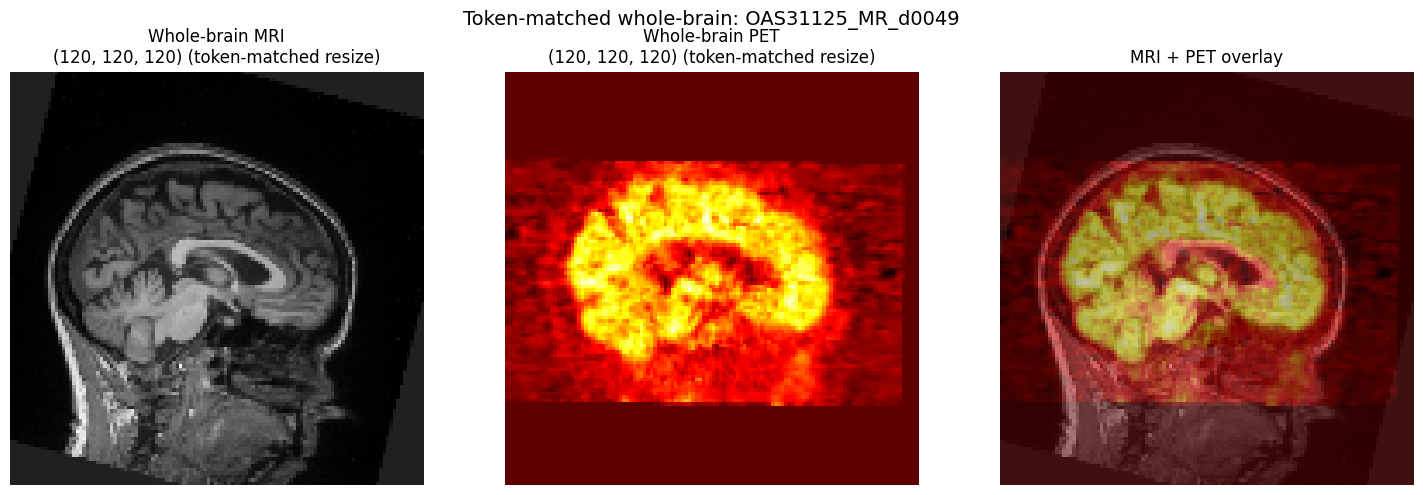

MRI shape: (120, 120, 120) -> 3375 tokens at patch_size=8
PET shape: (120, 120, 120) -> 3375 tokens at patch_size=8


In [10]:
import matplotlib.pyplot as plt

session_id = X_val[0]
subject_id = session_to_subject[session_id]

mri_orig = np.load(f"{WB_MRI_CACHE_AUG}/{session_id}_orig.npy")
pet_orig = np.load(f"{WB_PET_CACHE_AUG}/{subject_id}_orig.npy")

mid = mri_orig.shape[0] // 2  # middle slice along the first axis

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mri_orig[mid, :, :], cmap='gray')
axes[0].set_title(f'Whole-brain MRI\n{mri_orig.shape} (token-matched resize)')
axes[0].axis('off')

axes[1].imshow(pet_orig[mid, :, :], cmap='hot')
axes[1].set_title(f'Whole-brain PET\n{pet_orig.shape} (token-matched resize)')
axes[1].axis('off')

# overlay: MRI in gray, PET in hot colormap with transparency
axes[2].imshow(mri_orig[mid, :, :], cmap='gray')
axes[2].imshow(pet_orig[mid, :, :], cmap='hot', alpha=0.5)
axes[2].set_title('MRI + PET overlay')
axes[2].axis('off')

plt.suptitle(f'Token-matched whole-brain: {session_id}', fontsize=14)
plt.tight_layout()
plt.show()

print(f"MRI shape: {mri_orig.shape} -> {(mri_orig.shape[0]//8)**3} tokens at patch_size=8")
print(f"PET shape: {pet_orig.shape} -> {(pet_orig.shape[0]//8)**3} tokens at patch_size=8")